**Project Scope**
- Dataset: Jeopardy! Questions Dataset
- Course techniques: Text mining, TF-IDF analysis, embeddings, text-based classification and similarity analysis
-  External techniques:Topic modeling, transformer-based embeddings, semantic clustering.

In [1]:
import numpy as np
import pandas as pd
import os

df = pd.read_csv(r"/content/JEOPARDY_CSV.csv")
df.head()

,Show Number,Air Date,Round,Category,Value,Question,Answer
0,4680,2004-12-31,Jeopardy!,HISTORY,$200,"For the last 8 years of his life, Galileo was ...",Copernicus
1,4680,2004-12-31,Jeopardy!,ESPN's TOP 10 ALL-TIME ATHLETES,$200,No. 2: 1912 Olympian; football star at Carlisl...,Jim Thorpe
2,4680,2004-12-31,Jeopardy!,EVERYBODY TALKS ABOUT IT...,$200,The city of Yuma in this state has a record av...,Arizona
3,4680,2004-12-31,Jeopardy!,THE COMPANY LINE,$200,"In 1963, live on ""The Art Linkletter Show"", th...",McDonald's
4,4680,2004-12-31,Jeopardy!,EPITAPHS & TRIBUTES,$200,"Signer of the Dec. of Indep., framer of the Co...",John Adams


/tmp/ipykernel_20471/2024412206.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


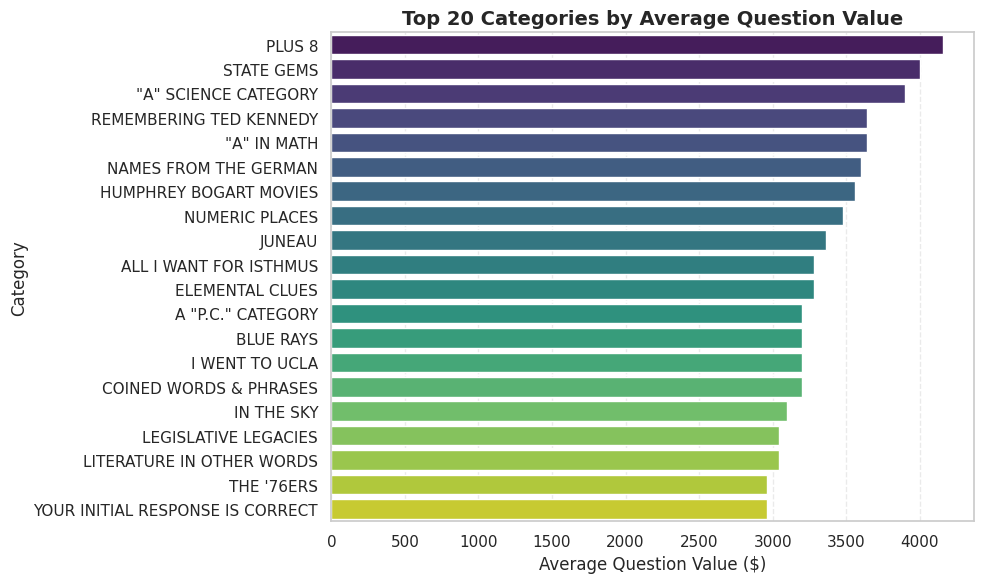

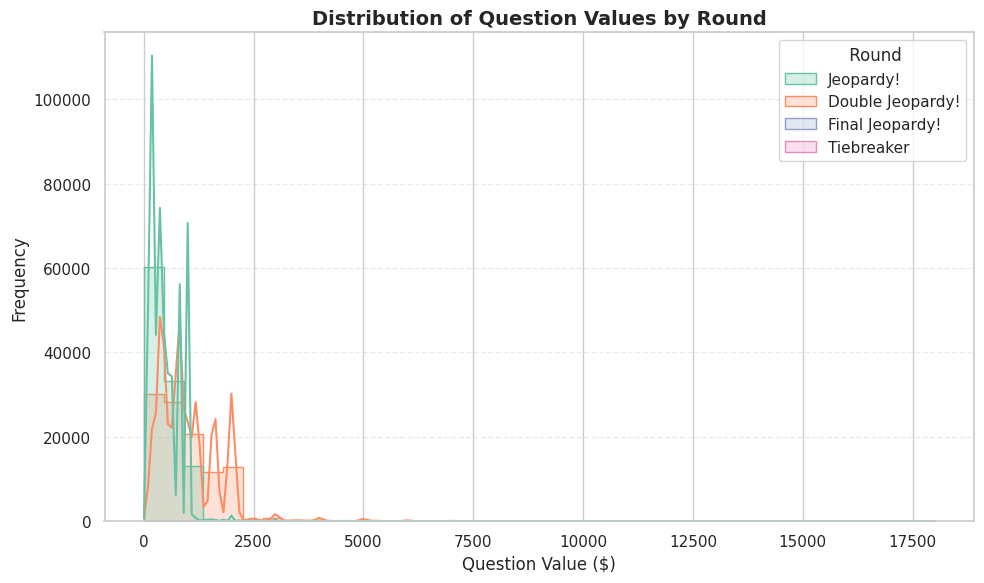

In [20]:
# ============================================================
# ADDITIONAL EDA (STYLED): VALUE & CATEGORY ANALYSIS
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. Categories with highest average question value
# ------------------------------------------------------------

category_vals = (
    df.groupby(' Category')['Value_Numeric']
      .mean()
      .sort_values(ascending=False)
      .head(20)
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_vals,
    x='Value_Numeric',
    y=' Category',
    palette='viridis'
)

plt.title('Top 20 Categories by Average Question Value', fontsize=14, fontweight='bold')
plt.xlabel('Average Question Value ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)


plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Distribution of question values by round
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Value_Numeric',
    hue=' Round',
    bins=40,
    kde=True,
    element='step',
    palette='Set2'
)

plt.title('Distribution of Question Values by Round', fontsize=14, fontweight='bold')
plt.xlabel('Question Value ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Additional EDA – Value and Category Analysis

We analyzed how question values vary across rounds and categories.

The distribution plot shows that Jeopardy! questions are concentrated at lower values, while Double Jeopardy! questions appear at higher values. Final Jeopardy! and Tiebreaker have very few data points.
The category plot shows the top 20 categories ranked by average question value, indicating which categories tend to have higher-valued questions in the dataset.

Overall, this step helps us understand how question values are distributed across rounds and how they differ across categories

**Research Questions**
- **RQ1**: Can we automatically group Jeopardy questions into meaningful semantic clusters beyond manually assigned categories?<br>
  - **Data mining task type** – Unsupervised text clustering / semantic grouping.<br>
  **Relevant algorithm(s)** – TF-IDF + cosine similarity (course), K-Means clustering (course), transformer-based embeddings (external).<br>
  **Evaluation criteria** – Cluster coherence, semantic similarity within clusters, interpretability vs. existing categories.
- **RQ2**: How do themes and knowledge domains in Jeopardy questions evolve over time, and what latent topic structures emerge across decades of episodes?
  - **Data mining task type** – Temporal text mining / topic trend analysis.<br>
  **Relevant algorithm(s)** – TF-IDF + keyword frequency trends (course), topic modeling (external), embedding-based similarity over time (external).<br>
  **Evaluation criteria** – Topic consistency over time, interpretability of trends, alignment with known category shifts.
- **RQ3**: To what extent can the difficulty (monetary value) of a Jeopardy question be predicted from its textual content and metadata?<br>
  - **Data mining task type** – Supervised learning (regression / classification).<br>
  **Relevant algorithm(s)** – TF-IDF features + regression/classification models (course), embedding-based representations (course/external), transformer embeddings (external).<br>
  **Evaluation criteria** – Prediction accuracy (RMSE / MAE), generalization performance, feature interpretability.



**Motivation and Feasibility**

- **RQ1: Semantic Clustering**<br>
  - **Motivation:** EDA shows a large category space (~27k) with inconsistencies, suggesting manual labels are noisy and incomplete.<br>
  **Non-triviality:** Existing categories do not capture semantic similarity across questions.<br>
  **Feasibility:** TF-IDF + clustering is straightforward; embeddings can improve semantic grouping.<br>
  **Risks:** High dimensionality and sensitivity to number of clusters.<br>
- **RQ2: Topic Evolution Over Time**<br>
  - **Motivation:** EDA shows category usage fluctuates across years rather than remaining stable.<br>
  **Non-triviality:** Manual categories do not reveal latent themes or temporal structure.<br>
  **Feasibility:** Grouping by year with text features is simple; topic modeling adds structure.<br>
  **Risks:** Topics may be hard to interpret; some years may have sparse data.<br>
- **RQ3: Difficulty Prediction**<br>
  - **Motivation:** EDA shows variation in question values across categories.<br>
  **Non-triviality:** Difficulty is implicit and only approximated using monetary value.<br>
  **Feasibility:** Regression using TF-IDF and embeddings is standard and implementable.<br>
  **Risks:** Weak signal in text may limit prediction performance.<br>

**Methodological Planning**

  - **RQ1: Semantic Clustering**<br>
    - **Course algorithms:** TF-IDF + cosine similarity, K-Means.<br>
    **External algorithms:** Transformer-based embeddings + clustering.<br>
    **Evaluation:** Cluster coherence and interpretability.<br>
    **Baseline:** Existing category labels.<br>
  - **RQ2: Topic Evolution**<br>
    - **Course algorithms:** TF-IDF + keyword frequency trends over time.<br>
    **External algorithms:** Topic modeling, embedding-based similarity.<br>
    **Evaluation:** Topic consistency and interpretability of temporal trends.<br>
    **Baseline:** Raw category frequency trends.<br>
  - **RQ3: Difficulty Prediction**<br>
    - **Course algorithms:** TF-IDF features + regression/classification models.<br>
    **External algorithms:** Embedding-based representations.<br>
    **Evaluation:** RMSE / MAE and generalization performance.<br>
    **Baseline:** Predicting mean or median value.

| RQ                    | Task Type                    | Course Methods      | External Methods       | Evaluation             |
| --------------------- | ---------------------------- | ------------------- | ---------------------- | ---------------------- |
| Semantic Clustering   | Unsupervised text clustering | TF-IDF, K-Means     | Transformer embeddings | Cluster coherence      |
| Topic Evolution       | Temporal text mining         | TF-IDF trends       | Topic modeling         | Topic interpretability |
| Difficulty Prediction | Supervised learning          | TF-IDF + regression | Embeddings             | RMSE / MAE             |


```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions

3. AI Tools:
- ChatGPT: I gave it the dataset and asked it for inspiration on what kind of questions we can seek to answer, I asked it to generate the write-ups needed for this checkopoint. I also asked it for code on the EDA steps, passed it my outputs and corrected hallucinations.
```

(F) Github Portfolio
- https://github.com/mihirsanjay-tamu/CSCE-676-Data-Mining-Project/tree/main